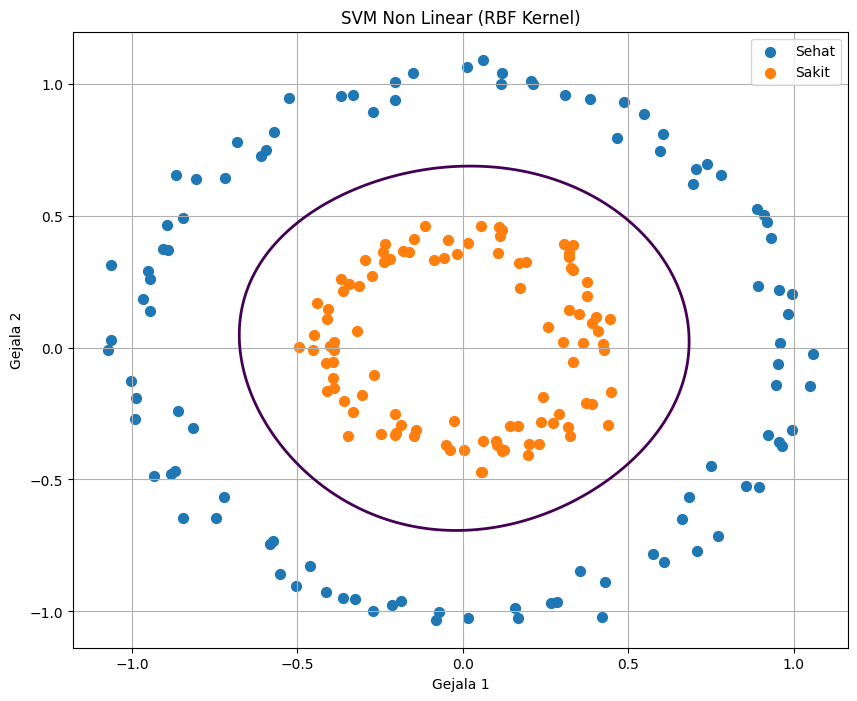

In [1]:
# ==========================================================
# SVM NON LINEAR
# Kasus: Deteksi Penyakit
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.datasets import make_circles

# ==========================================================
# MEMBUAT DATA NON LINEAR
# ==========================================================

X, y = make_circles(
    n_samples=200,
    factor=0.4,
    noise=0.05,
    random_state=42
)

# ==========================================================
# MODEL SVM NON LINEAR (RBF)
# ==========================================================

model = SVC(
    kernel='rbf',
    C=1,
    gamma='scale'
)

model.fit(X, y)

# ==========================================================
# VISUALISASI
# ==========================================================

plt.figure(figsize=(10,8))

# Scatter plot
plt.scatter(
    X[y==0][:,0],
    X[y==0][:,1],
    s=50,
    label='Sehat'
)

plt.scatter(
    X[y==1][:,0],
    X[y==1][:,1],
    s=50,
    label='Sakit'
)

# ==========================================================
# DECISION BOUNDARY
# ==========================================================

ax = plt.gca()

xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(xlim[0], xlim[1], 500)
yy = np.linspace(ylim[0], ylim[1], 500)

YY, XX = np.meshgrid(yy, xx)

xy = np.vstack([XX.ravel(), YY.ravel()]).T

Z = model.decision_function(xy).reshape(XX.shape)

# Boundary
ax.contour(
    XX,
    YY,
    Z,
    levels=[0],
    linewidths=2
)

# ==========================================================
# LABEL
# ==========================================================

plt.title("SVM Non Linear (RBF Kernel)")

plt.xlabel("Gejala 1")
plt.ylabel("Gejala 2")

plt.legend()

plt.grid(True)

plt.show()